In [1]:
import xarray as xr
import lonboard
from lonboard import viz
from zarr.storage import ObjectStore
import numpy as np
import geopandas as gpd
import matplotlib
import pandas as pd

from obstore.store import GCSStore, from_url

In [2]:
store = GCSStore(
    bucket="gcp-public-data-arco-era5/",
    prefix="ar",
    skip_signature=True,
)

In [3]:
store.list_with_delimiter()

{'common_prefixes': ['1959-2022-1h-240x121_equiangular_with_poles_conservative.zarr',
  '1959-2022-1h-360x181_equiangular_with_poles_conservative.zarr',
  '1959-2022-6h-128x64_equiangular_conservative.zarr',
  '1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr',
  '1959-2022-6h-1440x721.zarr',
  '1959-2022-6h-240x121_equiangular_with_poles_conservative.zarr',
  '1959-2022-6h-512x256_equiangular_conservative.zarr',
  '1959-2022-6h-64x32_equiangular_conservative.zarr',
  '1959-2022-6h-64x32_equiangular_with_poles_conservative.zarr',
  '1959-2022-full_37-1h-0p25deg-chunk-1.zarr-v2',
  '1959-2022-full_37-6h-0p25deg-chunk-1.zarr-v2',
  '1959-2022-full_37-6h-0p25deg_derived.zarr',
  '1959-2022-wb13-6h-0p25deg-chunk-1.zarr-v2',
  '1959-2023_01_10-6h-64x32_equiangular_conservative.zarr',
  '1959-2023_01_10-full_37-1h-0p25deg-chunk-1.zarr',
  '1959-2023_01_10-full_37-1h-1440x721.zarr',
  'full_37-1h-0p25deg-chunk-1.zarr-v3',
  'model-level-1h-0p25deg.zarr-v1',
  'model-level-1h-0p25d

In [4]:
ds = xr.open_zarr(
    ObjectStore(
        GCSStore.from_url("gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
        skip_signature=True)),
    decode_timedelta=True
    )  

In [5]:
ds

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * time                                                             (time) datetime64[ns] 11MB ...
  * latitude                                                         (latitude) float32 3kB ...
  * longitude                                                        (longitude) float32 6kB ...
  * level                                                            (level) int64 296B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 5TB ...
Attributes:
    last_updated:           2026-03-20 14:18:41.776541+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-03-14

In [6]:
temp = ds["2m_temperature"].sel(time="2000-01-01T12:00").compute()

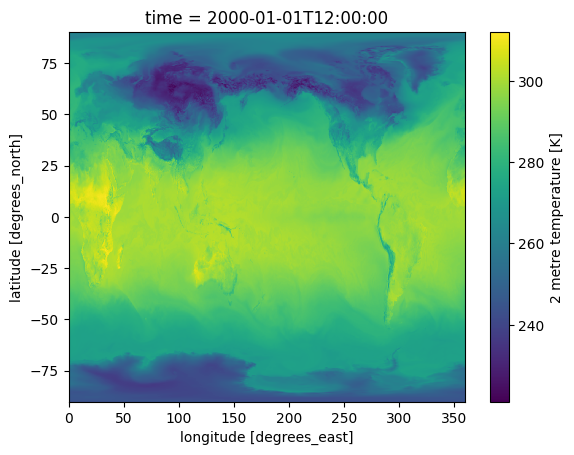

In [7]:
temp.plot()

In [8]:
forecast = xr.open_zarr(
    "https://data.dynamical.org/ecmwf/ifs-ens/forecast-15-day-0-25-degree/latest.zarr",                       
)  

In [9]:
forecast

<xarray.Dataset> Size: 246TB
Dimensions:                                     (init_time: 719, lead_time: 85,
                                                 ensemble_member: 51,
                                                 latitude: 721, longitude: 1440)
Coordinates:
  * init_time                                   (init_time) datetime64[ns] 6kB ...
    expected_forecast_length                    (init_time) timedelta64[ns] 6kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 6kB ...
  * lead_time                                   (lead_time) timedelta64[ns] 680B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 489kB ...
  * ensemble_member                             (ensemble_member) int16 102B ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
Data variables: (12/19)
    categorical_precipitation_type_surface      (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    dew_point_temperature_2m                    (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    geopotential_height_500hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    geopotential_height_850hpa                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    ...                                          ...
    total_cloud_cover_atmosphere                (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    wind_gust_10m                               (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    wind_u_100m                                 (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    wind_u_10m                                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    wind_v_100m                                 (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
    wind_v_10m                                  (init_time, lead_time, ensemble_member, latitude, longitude) float32 13TB ...
Attributes:
    dataset_id:           ecmwf-ifs-ens-forecast-15-day-0-25-degree
    dataset_version:      0.1.0
    name:                 ECMWF IFS ENS Forecast, 15 day, 0.25 degree
    description:          Ensemble weather forecasts from the ECMWF Integrate...
    attribution:          ECMWF IFS ENS Forecast data processed by dynamical....
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2024-04-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 24 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  Forecast step 0-144 hours: 3 hourly, 144-360 hours:...

In [15]:
t2_forecast = forecast["temperature_2m"].sel(init_time="2026-03-19T00", lead_time=pd.Timedelta(0), ensemble_member=0)

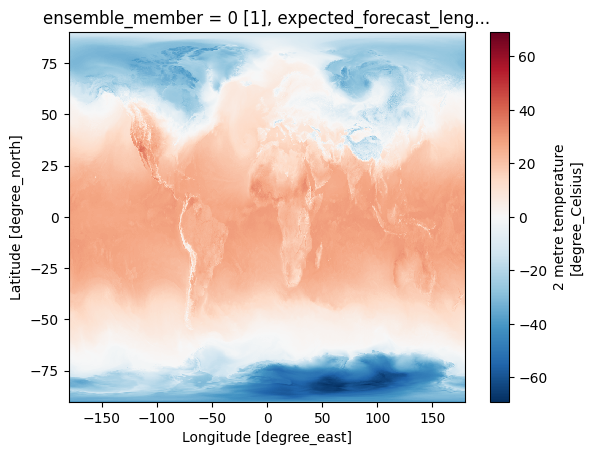

In [16]:
t2_forecast.plot()